# 🤖 Notebook 3 — Full Research Agent

> **Goal of this notebook:** wire everything we built in Notebooks 1 and 2 into a single
> end-to-end system — from a vague user message to a finished research report.

---

## 🗺️ The big picture

In the previous notebooks we built two phases independently:

| Notebook | Phase | What it does |
|---|---|---|
| Notebook 1 | **Scope** | Clarifies the request, generates a research brief |
| Notebook 2 | **Research** | Searches the web, compresses findings |
| **This notebook** | **Full pipeline** | Connects both + adds final report generation |

Here is the complete flow:

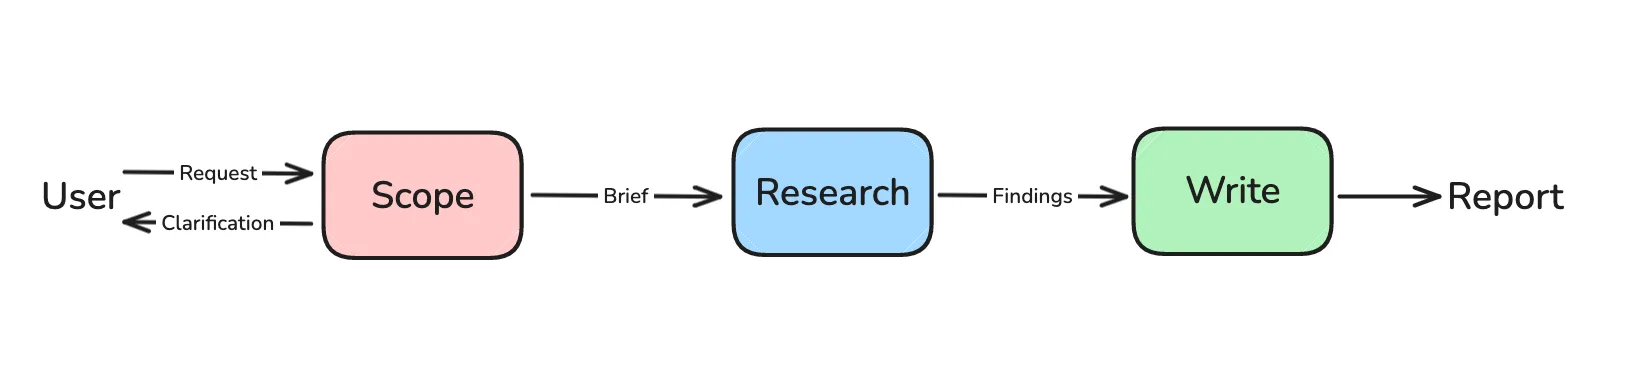

We now add one final node — **`final_report_generation`** — that reads the compressed
research and writes a polished, structured report.


---

## 🗂️ Notebook structure

1. ⚙️ Setup
2. 💬 The final report prompt
3. ⚡ The new node — `final_report_generation`
4. 🔗 Assembling the full graph
5. 🚀 Run it end-to-end

---
## ⚙️ Step 0 — Setup

Same keys as before — Groq, Tavily, and LangSmith.

In [1]:
# ============================================================
# 🔑  Enter your API keys here before running the notebook
# ============================================================
import os

# Groq — https://console.groq.com (free)
GROQ_API_KEY = ""

# Tavily — https://app.tavily.com (free, 1 000 credits/month, no credit card)
TAVILY_API_KEY = ""

# LangSmith — https://smith.langchain.com (free)
LANGSMITH_API_KEY = ""
LANGSMITH_TRACING = "true"
LANGSMITH_PROJECT = "deep_research_from_scratch"

os.environ["GROQ_API_KEY"]      = GROQ_API_KEY
os.environ["TAVILY_API_KEY"]    = TAVILY_API_KEY
os.environ["LANGSMITH_API_KEY"] = LANGSMITH_API_KEY
os.environ["LANGSMITH_TRACING"] = LANGSMITH_TRACING
os.environ["LANGSMITH_PROJECT"] = LANGSMITH_PROJECT

%load_ext autoreload
%autoreload 2

print("✅ API keys configured!")

✅ API keys configured!


---
## ♻️ Step 1 — What we reuse from previous notebooks

The power of building everything with `%%writefile` is that every component is already
saved as a proper Python module. We import directly — no code duplication.

| Component | Source file | Built in |
|---|---|---|
| `AgentState`, `AgentInputState` | `state_scope.py` | Notebook 1 |
| `clarify_with_user` | `research_agent_scope.py` | Notebook 1 |
| `write_research_brief` | `research_agent_scope.py` | Notebook 1 |
| `researcher_agent` | `research_agent.py` | Notebook 2 |
| `get_today_str` | `utils.py` | Notebook 2 |

The only new thing we write in this notebook is **`final_report_generation`** — one node
that reads the compressed research and writes the final report.

In [2]:
# Verify all imports work before building the graph
from deep_research_from_scratch.state_scope import AgentState, AgentInputState
from deep_research_from_scratch.research_agent_scope import clarify_with_user, write_research_brief
from deep_research_from_scratch.research_agent import researcher_agent
from deep_research_from_scratch.utils import get_today_str

print("✅ All components imported successfully")
print()
print("From Notebook 1:")
print(f"  AgentState            — {AgentState}")
print(f"  clarify_with_user     — {clarify_with_user.__name__}")
print(f"  write_research_brief  — {write_research_brief.__name__}")
print()
print("From Notebook 2:")
print(f"  researcher_agent      — {type(researcher_agent).__name__}")
print(f"  get_today_str()       — {get_today_str()}")

✅ All components imported successfully

From Notebook 1:
  AgentState            — <class 'deep_research_from_scratch.state_scope.AgentState'>
  clarify_with_user     — clarify_with_user
  write_research_brief  — write_research_brief

From Notebook 2:
  researcher_agent      — CompiledStateGraph
  get_today_str()       — Mon Jun 1, 2026


---
## 🌉 Step 2 — The bridge node: connecting Phase 1 to Phase 2

### The handoff problem

After `write_research_brief` runs, the research brief is stored in `AgentState`.
But `researcher_agent` (from Notebook 2) expects a `ResearcherState` with a
`researcher_messages` field — a completely different state type.

We need a **bridge node** that:
1. Reads `research_brief` from `AgentState`
2. Runs `researcher_agent` with it
3. Writes the results back into `AgentState`

This is the glue between the two phases.

### What `researcher_agent` returns

Looking back at Notebook 2, `researcher_agent` returns a `ResearcherOutputState`:
```python
{
    "compressed_research": "...",   ← the clean summary
    "raw_notes": ["..."],           ← all raw tool outputs
    "researcher_messages": [...]    ← the full trajectory
}
```

The bridge node extracts `compressed_research` and stores it in `AgentState.notes`
so the final report node can read it.

In [3]:
# Inspect what researcher_agent actually returns
# (run this after Notebook 2 is set up — it confirms the output schema)
from deep_research_from_scratch.research_agent import researcher_agent
from deep_research_from_scratch.state_research import ResearcherOutputState

print("researcher_agent output schema fields:")
for field, ftype in ResearcherOutputState.__annotations__.items():
    print(f"  {field:<30} {str(ftype)[:60]}")

researcher_agent output schema fields:
  compressed_research            <class 'str'>
  raw_notes                      typing.Annotated[typing.List[str], <built-in function add>]
  researcher_messages            typing.Annotated[typing.Sequence[langchain_core.messages.bas


---
## 💬 Step 3 — The final report prompt

### What makes a good report prompt?

The final report node receives:
- The original **research brief** (what was asked for)
- The **compressed findings** from the research agent

Its job is to synthesise these into a polished, structured document.

The prompt needs to tell the model:
1. What format to use (markdown, headers, citations)
2. How to handle conflicting or missing information
3. What length and depth is appropriate

Let's read the actual prompt.

In [4]:
from utils import show_prompt
from deep_research_from_scratch.prompts import final_report_generation_prompt

show_prompt(final_report_generation_prompt, "Final Report Generation Prompt")

╭──────────────────────────────────────── Final Report Generation Prompt ─────────────────────────────────────────╮
│                                                                                                                 │
│  Based on all the research conducted, create a comprehensive, well-structured answer to the overall research    │
│  brief:                                                                                                         │
│  <Research Brief>                                                                                               │
│  {research_brief}                                                                                               │
│  </Research Brief>                                                                                              │
│                                                                                                                 │
│  CRITICAL: Make sure the answer is written in the same language as the human messages!                          │
│  For example, if the user's messages are in English, then MAKE SURE you write your response in English. If the  │
│  user's messages are in Chinese, then MAKE SURE you write your entire response in Chinese.                      │
│  This is critical. The user will only understand the answer if it is written in the same language as their      │
│  input message.                                                                                                 │
│                                                                                                                 │
│  Today's date is {date}.                                                                                        │
│                                                                                                                 │
│  Here are the findings from the research that you conducted:                                                    │
│  <Findings>                                                                                                     │
│  {findings}                                                                                                     │
│  </Findings>                                                                                                    │
│                                                                                                                 │
│  Please create a detailed answer to the overall research brief that:                                            │
│  1. Is well-organized with proper headings (# for title, ## for sections, ### for subsections)                  │
│  2. Includes specific facts and insights from the research                                                      │
│  3. References relevant sources using [Title](URL) format                                                       │
│  4. Provides a balanced, thorough analysis. Be as comprehensive as possible, and include all information that   │
│  is relevant to the overall research question. People are using you for deep research and will expect           │
│  detailed, comprehensive answers.                                                                               │
│  5. Includes a "Sources" section at the end with all referenced links                                           │
│                                                                                                                 │
│  You can structure your report in a number of different ways. Here are some examples:                           │
│                                                                                                                 │
│  To answer a question that asks you to compare two things, you might structure your report like this:           │
│  1/ intro                                                                                                       │
│  2/ overview of topic A                               

### What to notice in this prompt

- **`{research_brief}`** — re-states the original question so the model doesn't drift
- **`{findings}`** — the compressed research from Notebook 2
- **`{date}`** — so the model can reference when the research was done
- The prompt asks for **structured markdown output** — headers, bullet points, citations

> **Notice:** this is the *only* node that doesn't use `with_structured_output()`.
> The report is free-form markdown — there's no fixed schema to enforce.
> We trust the prompt to control the format.

---
## ⚡ Step 4 — The new node: `final_report_generation`

### Node pattern — same as always

Every node does three things:
1. Read from state
2. Call the LLM
3. Write back to state

```
reads:  state["notes"]           ← compressed research from bridge node
        state["research_brief"]  ← the original brief from Notebook 1
writes: state["final_report"]    ← the finished report
        state["messages"]        ← appends a confirmation message
```

### Why `notes` and not `compressed_research`?

`AgentState` (from Notebook 1) has a field called `notes` — not `compressed_research`.
`compressed_research` lives in `ResearcherState` (Notebook 2).
The bridge node copies `compressed_research` → `notes` when crossing between states.

In [5]:
%%writefile ../src/deep_research_from_scratch/research_agent_full.py

"""Full Research Pipeline — scoping + research + report generation."""

from langchain_core.messages import HumanMessage
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver

from deep_research_from_scratch.utils import get_today_str
from deep_research_from_scratch.prompts import final_report_generation_prompt
from deep_research_from_scratch.state_scope import AgentState, AgentInputState
from deep_research_from_scratch.research_agent_scope import clarify_with_user, write_research_brief
from deep_research_from_scratch.research_agent import researcher_agent


# ══════════════════════════════════════════════════════
# MODEL
# ══════════════════════════════════════════════════════

# Same model as the rest of the course — consistent and free
writer_model = ChatGroq(model="llama-3.3-70b-versatile", temperature=0.0, max_tokens=4000)


# ══════════════════════════════════════════════════════
# BRIDGE NODE — run_research
# Connects Phase 1 (AgentState) to Phase 2 (ResearcherState)
# Reads  : state["research_brief"]
# Writes : state["notes"], state["raw_notes"]
# ══════════════════════════════════════════════════════

def run_research(state: AgentState) -> dict:
    """Bridge node: invoke the research agent and store results in AgentState."""
    research_brief = state.get("research_brief", "")

    # Run the research agent from Notebook 2
    # It takes a ResearcherState input, returns ResearcherOutputState
    result = researcher_agent.invoke({
        "researcher_messages": [HumanMessage(content=f"{research_brief}.")]
    })

    # Bridge the results back into AgentState
    return {
        "notes":     [result["compressed_research"]],   # ← store as a list item
        "raw_notes": result["raw_notes"],                # ← raw tool outputs
    }


# ══════════════════════════════════════════════════════
# NODE — final_report_generation
# Reads  : state["notes"], state["research_brief"]
# Writes : state["final_report"], state["messages"]
# ══════════════════════════════════════════════════════

def final_report_generation(state: AgentState) -> dict:
    """Synthesise all research findings into a comprehensive final report."""

    # Join all note chunks into one findings string
    findings = "\n\n".join(state.get("notes", []))

    # Format the prompt with real data from state
    prompt = final_report_generation_prompt.format(
        research_brief=state.get("research_brief", ""),
        findings=findings,
        date=get_today_str(),
    )

    # Call the model — free-form markdown, no structured output schema
    response = writer_model.invoke([HumanMessage(content=prompt)])

    return {
        "final_report": response.content,
        "messages":     [HumanMessage(content="Here is your final report:\n\n" + response.content)],
    }


# ══════════════════════════════════════════════════════
# GRAPH CONSTRUCTION
# Full pipeline: scope → research → report
# ══════════════════════════════════════════════════════

deep_researcher_builder = StateGraph(AgentState, input_schema=AgentInputState)

# ── Nodes ────────────────────────────────────────────
deep_researcher_builder.add_node("clarify_with_user",       clarify_with_user)      # NB1
deep_researcher_builder.add_node("write_research_brief",    write_research_brief)   # NB1
deep_researcher_builder.add_node("run_research",            run_research)           # bridge
deep_researcher_builder.add_node("final_report_generation", final_report_generation) # new

# ── Edges ────────────────────────────────────────────
deep_researcher_builder.add_edge(START,                    "clarify_with_user")
# clarify_with_user uses Command internally → routes to write_research_brief or END
deep_researcher_builder.add_edge("write_research_brief",   "run_research")
deep_researcher_builder.add_edge("run_research",           "final_report_generation")
deep_researcher_builder.add_edge("final_report_generation", END)

Overwriting ../src/deep_research_from_scratch/research_agent_full.py


### 🔍 Key design decisions in this code

**Why a separate `run_research` bridge node?**

We could have put the `researcher_agent.invoke()` call inside `final_report_generation`,
but keeping them separate is cleaner:
- `run_research` = data gathering
- `final_report_generation` = writing

Each node has one responsibility. If research fails, it fails cleanly without touching the report node.

**Why `notes` as a `list` item?**

`AgentState.notes` uses `operator.add` — it's designed for parallel agents to append to it.
Even though we only have one research agent here, we store the result as `[compressed_research]`
(a single-item list) so the state type contract is respected.

**Why synchronous (`invoke`) instead of async (`ainvoke`)?**

The original notebook used `async/await` with `ainvoke`. We use plain `invoke` because:
- Jupyter on Windows has limited async support
- Groq's API is fast enough that async provides minimal benefit for a single agent
- Simpler code = easier to teach

---
## 🔗 Step 5 — Compile & visualise the full graph

Now let's compile and see the complete pipeline.

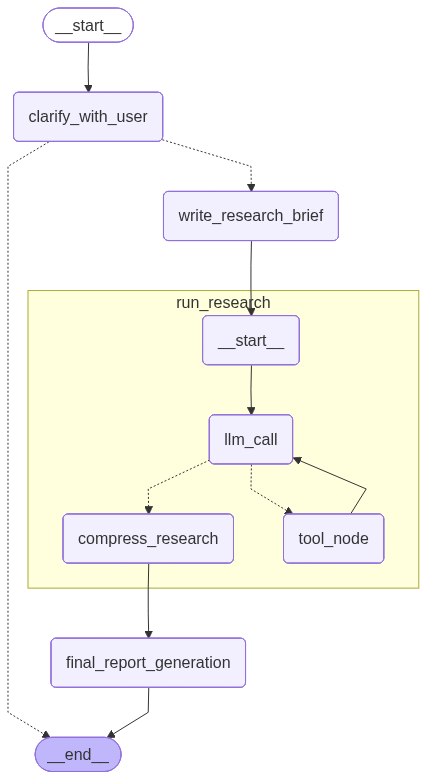

In [6]:
from IPython.display import Image, display
from langgraph.checkpoint.memory import InMemorySaver
from deep_research_from_scratch.research_agent_full import deep_researcher_builder

checkpointer = InMemorySaver()
full_agent = deep_researcher_builder.compile(checkpointer=checkpointer)

display(Image(full_agent.get_graph(xray=True).draw_mermaid_png()))

**Read the diagram:**

| Arrow | What it means |
|---|---|
| `START → clarify_with_user` | Always starts with clarification |
| `clarify_with_user → END` | If request is too vague — ask the user and stop |
| `clarify_with_user → write_research_brief` | If clear enough — write the brief |
| `write_research_brief → run_research` | Brief is ready — run the research agent |
| `run_research → final_report_generation` | Research done — write the report |
| `final_report_generation → END` | Always finishes here |

**Notice** that `clarify_with_user`'s routing (the diamond split) still works exactly as in Notebook 1 —
it uses `Command` internally. The rest of the edges are static.

---
## 🚀 Step 6 — Run it end-to-end

We follow the same two-call pattern as Notebook 1:
1. Send a vague message → agent asks for clarification
2. Reply with details → full pipeline runs to completion

Both calls use the **same `thread_id`** so the agent remembers the conversation.

In [7]:
from utils import format_messages
from langchain_core.messages import HumanMessage

thread = {"configurable": {"thread_id": "1"}, "recursion_limit": 50}

# ── Call 1: vague input ───────────────────────────────────────
print("=" * 55)
print("CALL 1 — Vague request")
print("=" * 55)

result = full_agent.invoke(
    {"messages": [HumanMessage(content="I want to research coffee shops.")]},
    config=thread
)

format_messages(result['messages'])

CALL 1 — Vague request


╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ I want to research coffee shops.                                                                                │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ What specific aspects of coffee shops would you like to research (e.g. * market trends, * consumer behavior, *  │
│ business operations, * product offerings)?                                                                      │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

**What happened?**

The pipeline entered `clarify_with_user`, the LLM decided `need_clarification=True`,
and the `Command` routed to `END` — returning a question without running research or the report.

This is identical to Notebook 1. The scoping phase works exactly the same inside the full pipeline.

In [8]:
# ── Call 2: detailed reply in the same thread ────────────────
print("=" * 55)
print("CALL 2 — Detailed reply (same thread_id='1')")
print("⏳ This will take 1–2 minutes — research is running...")
print("=" * 55)

result = full_agent.invoke(
    {"messages": [HumanMessage(
        content="Let's examine coffee quality to assess the best specialty coffee shops in San Francisco."
    )]},
    config=thread
)

print("\n✅ Done!")
print(f"   Messages in state : {len(result['messages'])}")
print(f"   Notes collected   : {len(result.get('notes', []))} chunk(s)")
print(f"   Final report      : {len(result.get('final_report', ''))} characters")

CALL 2 — Detailed reply (same thread_id='1')
⏳ This will take 1–2 minutes — research is running...

✅ Done!
   Messages in state : 5
   Notes collected   : 1 chunk(s)
   Final report      : 3913 characters


**What happened this time?**

The full pipeline ran:
1. `clarify_with_user` — saw the full conversation (both messages), decided `need_clarification=False`
2. `write_research_brief` — distilled the conversation into a brief
3. `run_research` — invoked `researcher_agent`, which searched the web and compressed findings
4. `final_report_generation` — read the compressed research and wrote the report

Let's inspect each output.

### 🔬 Inspect the conversation messages

In [9]:
from utils import format_messages
format_messages(result['messages'])

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ I want to research coffee shops.                                                                                │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ What specific aspects of coffee shops would you like to research (e.g. * market trends, * consumer behavior, *  │
│ business operations, * product offerings)?                                                                      │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ Let's examine coffee quality to assess the best specialty coffee shops in San Francisco.                        │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ I have sufficient information to proceed. You would like to research coffee quality to assess the best          │
│ specialty coffee shops in San Francisco. I will now begin the research process to provide you with the relevant │
│ information.                                                                                                    │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ Here is your final report:                                                                                      │
│                                                                                                                 │
│ # Introduction to Specialty Coffee in San Francisco                                                             │
│ San Francisco is renowned for its vibrant coffee culture, with a plethora of specialty coffee shops scattered   │
│ throughout the city. These establishments pride themselves on serving high-quality coffee, often sourced from   │
│ unique and exotic locations around the world. When evaluating the best specialty coffee shops in San Francisco, │
│ factors such as bean sourcing, roasting methods, brewing techniques, and taste are of paramount importance.     │
│ This report aims to provide a comprehensive overview of the top specialty coffee shops in San Francisco,        │
│ considering all relevant factors and price ranges.                                                              │
│                                                                                                                 │
│ ## Overview of Top-Rated Specialty Coffee Shops                                                                 │
│ According to [Yelp](https://www.yelp.com/search?find_desc=Specialty+Coffee&find_loc=San+Francisco%2C+CA), some  │
│ of the top-rated specialty coffee shops in San Francisco include Angel Cafe & Deli, Origin Lab Coffee & Matcha, │
│ and Third Wheel Coffee. These shops have received positive reviews from customers, with Angel Cafe & Deli       │
│ boasting an impressive 4.3-star rating out of 324 reviews. Origin Lab Coffee & Matcha has also received         │
│ acclaim, with a 4.4-star rating. Another notable mention is The Coffee Movement, which has been recommended by  │
│ users on                                                                                                        │
│ [Reddit](https://www.reddit.com/r/SFbitcheswithtaste/comments/1s25yox/favourite_speciality_bean_roasterscafes_i │
│ n_sf) for its unique approach to coffee.                                                                        │
│                                                                                                                 │
│ ## Bean Sourcing and Roasting Methods                                                                           │
│ The quality of coffee beans is a crucial factor in determining the overall taste and quality of the coffee.     │
│ Many specialty coffee shops in San Francisco source their beans from reputable roasters, both locally and       │
│ internationally. For example, [SF Bay                                                                           │
│ Coffee](https://sfbaycoffee.com/blogs/articles/espresso-beans-a-complete-guide) provides a comprehensive guide  │
│ to espresso beans, covering their history, characteristics, and how to choose the right beans for brewing. Some │
│ shops, such as HI-NRG and Paper Son, have been recommended for their unique and high-quality bean sourcing.     │
│                                                                                                                 │
│ ## Brewing Techniques and Taste                                                                                 │
│ Brewing techniques also play a significant role in bringing out the full flavor and potential of the coffee     │
│ beans. Many specialty coffee shops in San Francisco offer a range of brewing methods, including pour-overs,     │
│ lattes, and cappuccinos. The (https://wheatlesswanderlust.com/best-specialty-coffee-san-francisco) highlights   │
│ the importance of unique and expertly crafted brewing techniques in creating an exceptional coffee experience.  │
│ Some shops, such as The Coffee Movement and Golden Goat

### 🔬 Inspect the research brief (Phase 1 output)

In [10]:
from rich.markdown import Markdown

print("Research brief stored in state:")
print("=" * 55)
print(result.get("research_brief", "Not found"))

Research brief stored in state:
I want to research coffee quality to assess the best specialty coffee shops in San Francisco, considering all relevant factors such as bean sourcing, roasting methods, and brewing techniques, with a primary focus on taste, and I would like to consider all price ranges unless cost constraints are specified, using official websites of coffee shops and reputable review platforms as primary sources.


### 🔬 Inspect the compressed research (Phase 2 output)

In [11]:
notes = result.get("notes", [])
print(f"Notes chunks: {len(notes)}")
print("=" * 55)
if notes:
    print(notes[0][:1000], "..." if len(notes[0]) > 1000 else "")

Notes chunks: 1
**List of Queries and Tool Calls Made**

The AI researcher conducted the following searches and tool calls to gather information on the research topic:

1. Search query: "best specialty coffee shops in San Francisco"
2. Search query: "San Francisco specialty coffee shops bean sourcing roasting methods brewing techniques"
3. Search query: "San Francisco specialty coffee shops reviews Yelp Google Reviews"

**Fully Comprehensive Findings**

The research findings are as follows:

The best specialty coffee shops in San Francisco can be found by considering factors such as bean sourcing, roasting methods, brewing techniques, and taste. Some top-rated shops include Angel Cafe & Deli, Origin Lab Coffee & Matcha, Third Wheel Coffee, and The Coffee Movement. These shops offer a range of coffee options, from pour-overs to lattes, and have received positive reviews from customers.

According to Yelp, the top 10 best specialty coffee shops in San Francisco are:
* Angel Cafe & Deli. 

### 📄 The final report

In [12]:
from rich.markdown import Markdown
Markdown(result["final_report"])

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃                                Introduction to Specialty Coffee in San Francisco                                ┃
┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛

San Francisco is renowned for its vibrant coffee culture, with a plethora of specialty coffee shops scattered      
throughout the city. These establishments pride themselves on serving high-quality coffee, often sourced from      
unique and exotic locations around the world. When evaluating the best specialty coffee shops in San Francisco,    
factors such as bean sourcing, roasting methods, brewing techniques, and taste are of paramount importance. This   
report aims to provide a comprehensive overview of the top specialty coffee shops in San Francisco, considering all
relevant factors and price ranges.                                                                                 


                                   Overview of Top-Rated Specialty Coffee Shops                                    

According to ]8;id=507962;https://www.yelp.com/search?find_desc=Specialty+Coffee&find_loc=San+Francisco%2C+CA\Yelp]8;;\, some of the top-rated specialty coffee shops in San Francisco include Angel Cafe & Deli, Origin 
Lab Coffee & Matcha, and Third Wheel Coffee. These shops have received positive reviews from customers, with Angel 
Cafe & Deli boasting an impressive 4.3-star rating out of 324 reviews. Origin Lab Coffee & Matcha has also received
acclaim, with a 4.4-star rating. Another notable mention is The Coffee Movement, which has been recommended by     
users on ]8;id=644923;https://www.reddit.com/r/SFbitcheswithtaste/comments/1s25yox/favourite_speciality_bean_roasterscafes_in_sf\Reddit]8;;\ for its unique approach to coffee.                                                                 


                                        Bean Sourcing and Roasting Methods                                         

The quality of coffee beans is a crucial factor in determining the overall taste and quality of the coffee. Many   
specialty coffee shops in San Francisco source their beans from reputable roasters, both locally and               
internationally. For example, ]8;id=762853;https://sfbaycoffee.com/blogs/articles/espresso-beans-a-complete-guide\SF Bay Coffee]8;;\ provides a comprehensive guide to espresso beans, covering their       
history, characteristics, and how to choose the right beans for brewing. Some shops, such as HI-NRG and Paper Son, 
have been recommended for their unique and high-quality bean sourcing.                                             


                                           Brewing Techniques and Taste                                            

Brewing techniques also play a significant role in bringing out the full flavor and potential of the coffee beans. 
Many specialty coffee shops in San Francisco offer a range of brewing methods, including pour-overs, lattes, and   
cappuccinos. The ]8;id=191505;https://wheatlesswanderlust.com/best-specialty-coffee-san-francisco\blog post on wheatlesswanderlust.com]8;;\ highlights the importance of unique and expertly crafted     
brewing techniques in creating an exceptional coffee experience. Some shops, such as The Coffee Movement and Golden
Goat Coffee, have been praised for their skilled baristas and attention to detail in their brewing techniques.     


                                                    Conclusion                                                     

In conclusion, San Francisco's specialty coffee scene is vibrant and diverse, with a range of top-rated shops      
offering high-quality coffee and unique brewing techniques. When evaluating the best specialty coffee shops,       
factors such as bean sourcing, roasting methods, brewing techniques, and taste are all im

### 🔬 Make the full AgentState visible

In [13]:
print("All keys in the final AgentState:")
print(list(result.keys()))
print()

# Show what's populated vs empty
for key in result.keys():
    val = result[key]
    if isinstance(val, list):
        print(f"  {key:<25} list with {len(val)} item(s)")
    elif isinstance(val, str):
        print(f"  {key:<25} str — {len(val)} characters")
    elif val is None:
        print(f"  {key:<25} None (not populated)")
    else:
        print(f"  {key:<25} {type(val).__name__}")

All keys in the final AgentState:
['messages', 'research_brief', 'supervisor_messages', 'raw_notes', 'notes', 'final_report']

  messages                  list with 5 item(s)
  research_brief            str — 398 characters
  supervisor_messages       list with 1 item(s)
  raw_notes                 list with 1 item(s)
  notes                     list with 1 item(s)
  final_report              str — 3913 characters


---
## ✅ Summary — what we built

```
User message
     ↓
clarify_with_user  ──── need_clarification=True  → END (ask user)
     ↓ False
write_research_brief
     ↓
run_research  (bridge node)
  └── invokes researcher_agent from Notebook 2
  └── stores compressed_research → notes
     ↓
final_report_generation
  └── reads notes + research_brief
  └── writes final_report
     ↓
    END
```

### What this notebook added

| Concept | What it means |
|---|---|
| **Bridge node** | Translates between two different state types (`AgentState` ↔ `ResearcherState`) |
| **Reusing subgraphs** | `researcher_agent` is invoked as a black box — no code duplication |
| **`notes` as `list`** | Respects the `operator.add` contract even with a single agent |
| **Synchronous pipeline** | Plain `invoke` throughout — simpler, Windows-compatible |
| **`recursion_limit`** | Set to 50 to allow the research loop to run fully |

### The full 3-notebook journey

| Notebook | Phase | Key concept |
|---|---|---|
| 1 — Scoping | Clarify + brief | Structured output, State, Command routing |
| 2 — Research | Search + compress | Tool calling, agent loop, conditional edges |
| 3 — Full agent | End-to-end | Composing subgraphs, bridge nodes, state handoff |